In [3]:
import os
os.environ["KERAS_BACKEND"]="jax"
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

try:
    tpu= tf.distribute.cluster_resolver.TPUClusterResolver.Connect()
    print("Device: ",tpu.master())
    strategy= tf.distribute.TPUStrategy(tpu)
except:
    strategy= tf.distribute.get_strategy()
print("Number of replicas: ", strategy.num_replicas_in_sync)

/usr/local/lib/python3.12/site-packages/jax/_src/cloud_tpu_init.py:88: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


Number of replicas:  1


In [4]:
AUTOTUNE= tf.data.AUTOTUNE
BATCH_SIZE= 25*strategy.num_replicas_in_sync
IMAGE_SIZE= [180,180]
CLASS_NAMES=["NORMAL","PNEUMONIA"]

In [11]:
train_images= tf.data.TFRecordDataset(
    "gs://download.tensorflow.org/data/ChestXRay2017/train/images.tfrec"
)
train_paths= tf.data.TFRecordDataset(
    "gs://download.tensorflow.org/data/ChestXRay2017/train/paths.tfrec"
)
ds= tf.data.Dataset.zip((train_images,train_paths))

In [23]:
COUNT_NORMAL= len(
    [
        filename for filename in train_paths if "NORMAL" in filename.numpy().decode("utf-8")
    ]
)
print("Number of normal images in trainign set: "+ str(COUNT_NORMAL))
COUNT_PNEUMONIA= len(
    [
        filename for filename in train_paths if "PNEUMONIA" in filename.numpy().decode("utf-8")
    ]
)
print("Number of pneumonia images in training set: "+ str(COUNT_PNEUMONIA))

Number of normal images in trainign set: 1349
Number of pneumonia images in training set: 3883


In [13]:
def get_label(file_path):
    parts = tf.strings.split(file_path,"/")
    if parts[-2]=="PNEUMONIA":
        return 1
    else:
        return 0
def decode_img(img):
    img= tf.image.decode_jpeg(img, channels=3)
    return tf.image.resize(img, IMAGE_SIZE)
def process_path(image,path):
    label= get_label(path)
    img= decode_img(image)
    return img, label
ds= ds.map(process_path, num_parallel_calls=AUTOTUNE)

In [14]:
ds= ds.shuffle(10000)
train_ds= ds.take(4200)
val_ds= ds.skip(4200)
for image, label in train_ds.take(1):
    print("Image shape: ", image.numpy().shape)
    print("label: ",label.numpy())

Image shape:  (180, 180, 3)
label:  1


In [15]:
test_images = tf.data.TFRecordDataset(
    "gs://download.tensorflow.org/data/ChestXRay2017/test/images.tfrec"
)
test_paths = tf.data.TFRecordDataset(
    "gs://download.tensorflow.org/data/ChestXRay2017/test/paths.tfrec"
)
test_ds = tf.data.Dataset.zip((test_images, test_paths))

test_ds = test_ds.map(process_path, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE)


In [16]:
def prepare_for_training(ds, cache=True):
    if cache:
        if isinstance(cache,str):
            ds=ds.cache(cache)
        else:
            ds=ds.cache()
    ds=ds.batch(BATCH_SIZE)
    ds.prefetch(buffer_size=AUTOTUNE)
    return ds
train_ds= prepare_for_training(train_ds)
val_ds= prepare_for_training(val_ds)

image_batch, label_batch= next(iter(train_ds))


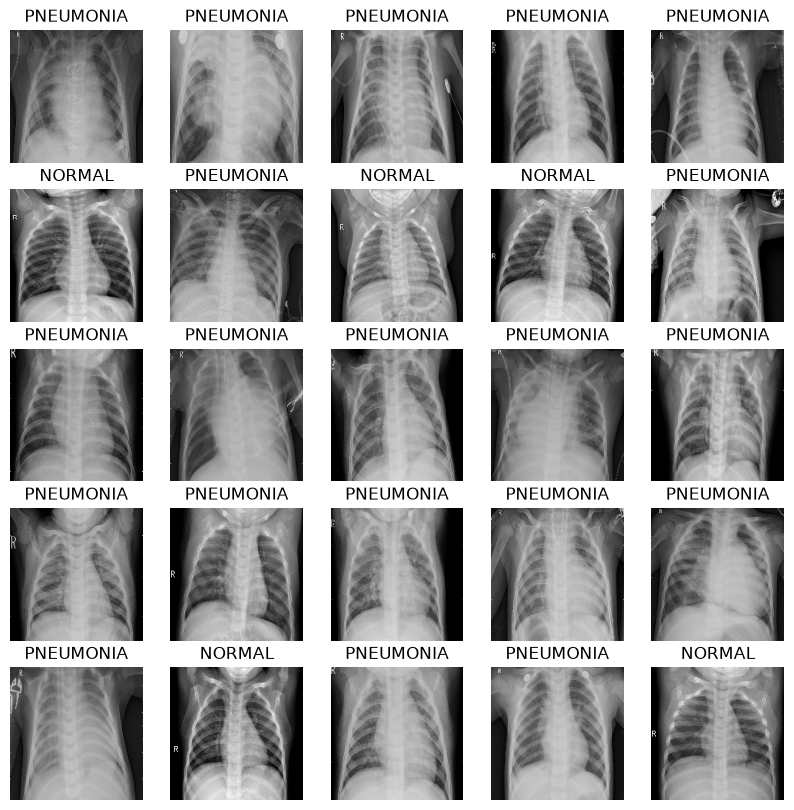

In [17]:
def show_batch(image_batch, label_batch):
    plt.figure(figsize=(10,10))
    for n in range(25):
        ax= plt.subplot(5,5,n+1)
        plt.imshow(image_batch[n]/255.0)
        if label_batch[n]:
            plt.title("PNEUMONIA")
        else:
            plt.title("NORMAL")
        plt.axis("off")
show_batch(image_batch.numpy(), label_batch.numpy())



In [20]:
import keras 
from keras import layers

def conv_block(filters, inputs):
    x= layers.SeparableConv2D(filters,3,activation="relu",padding="same",use_bias=False)(inputs)
    x= layers.SeparableConv2D(filters,3,activation="relu",padding="same",use_bias=False)(x)
    x= layers.BatchNormalization()(x)
    outputs= layers.MaxPool2D()(x)
    return outputs

def dense_block(units, dropout_rate, inputs):
    x= layers.Dense(units,activation="relu")(inputs)
    x= layers.BatchNormalization()(x)
    outputs= layers.Dropout(dropout_rate)(x)
    return outputs

In [21]:
def build_model():
    inputs= keras.Input(shape=(IMAGE_SIZE[0],IMAGE_SIZE[1],3))
    x= layers.Rescaling(1.0/255)(inputs)
    x= layers.Conv2D(16,3,activation="relu",padding="same")(x)
    x= layers.Conv2D(16,3,activation="relu", padding="same")(x)
    x= layers.MaxPool2D()(x)
    
    
    x= conv_block(32,x)
    x= conv_block(64,x)
    
    x=conv_block(128,x)
    x=layers.Dropout(0.2)(x)
    
    x= conv_block(256,x)
    x= layers.Dropout(0.2)(x)
    
    x= layers.Flatten()(x)
    x=dense_block(512,0.7,x)
    x=dense_block(128,0.5,x)
    x= dense_block(64,0.3,x)
    
    outputs= layers.Dense(1,activation="relu")(x)
    model= keras.Model(inputs=inputs, outputs=outputs, name="Pneumonia_model_base")
    return model
    

In [24]:
initial_bias= np.log([COUNT_PNEUMONIA/COUNT_NORMAL])
print(f"Initial bias: {initial_bias[0]:.5f}")
TRAIN_IMG_COUNT= COUNT_NORMAL +COUNT_PNEUMONIA

weight_for_0= (1/COUNT_NORMAL)*(TRAIN_IMG_COUNT)/2.0
weight_for_1=(1/COUNT_PNEUMONIA)*(TRAIN_IMG_COUNT)/2.0

class_weight={0: weight_for_0,
              1: weight_for_1
             }
print(f"Weight for class 0: {weight_for_0:.2f}")
print(f"Weight for class 1: {weight_for_1:.2f}")

Initial bias: 1.05724
Weight for class 0: 1.94
Weight for class 1: 0.67


In [31]:
checkpoint_cb= keras.callbacks.ModelCheckpoint("Pneumonia_model_base.keras",save_best_only=True)

early_stopping_cb= keras.callbacks.EarlyStopping(patience=15,restore_best_weights=True)

initial_learning_rate= 0.015
lr_schedule= keras.optimizers.schedules.ExponentialDecay(initial_learning_rate,decay_steps=10000, decay_rate=0.96, staircase=True)



In [33]:
with strategy.scope():
    model= build_model()
    METRICS=[
        keras.metrics.BinaryAccuracy(),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ]
    model.compile(
        optimizer= keras.optimizers.Adam(learning_rate=lr_schedule),
        loss="binary_crossentropy",
        metrics= METRICS,
    )
history= model.fit(
    train_ds,
    epochs=100,
    validation_data= val_ds,
    class_weight= class_weight,
    callbacks=[checkpoint_cb, early_stopping_cb],
)

Epoch 1/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step - binary_accuracy: 0.5529 - loss: 6.1225 - precision: 0.8051 - recall: 0.5206 - val_binary_accuracy: 0.7345 - val_loss: 4.2196 - val_precision: 0.7388 - val_recall: 0.9921
Epoch 2/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - binary_accuracy: 0.6693 - loss: 5.5128 - precision: 0.8204 - recall: 0.7070 - val_binary_accuracy: 0.6880 - val_loss: 4.8478 - val_precision: 0.7682 - val_recall: 0.8285
Epoch 3/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - binary_accuracy: 0.7348 - loss: 4.6148 - precision: 0.8480 - recall: 0.7808 - val_binary_accuracy: 0.7326 - val_loss: 4.2515 - val_precision: 0.7383 - val_recall: 0.9895
Epoch 4/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - binary_accuracy: 0.6848 - loss: 5.2518 - precision: 0.8278 - recall: 0.7237 - val_binary_accuracy: 0.7297 - val_loss: 4.1601 - val_precision: 0.7668 - val_recall: 0.9123
Epoch 5/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - binary_accuracy: 0.7231 - loss: 4.3874 

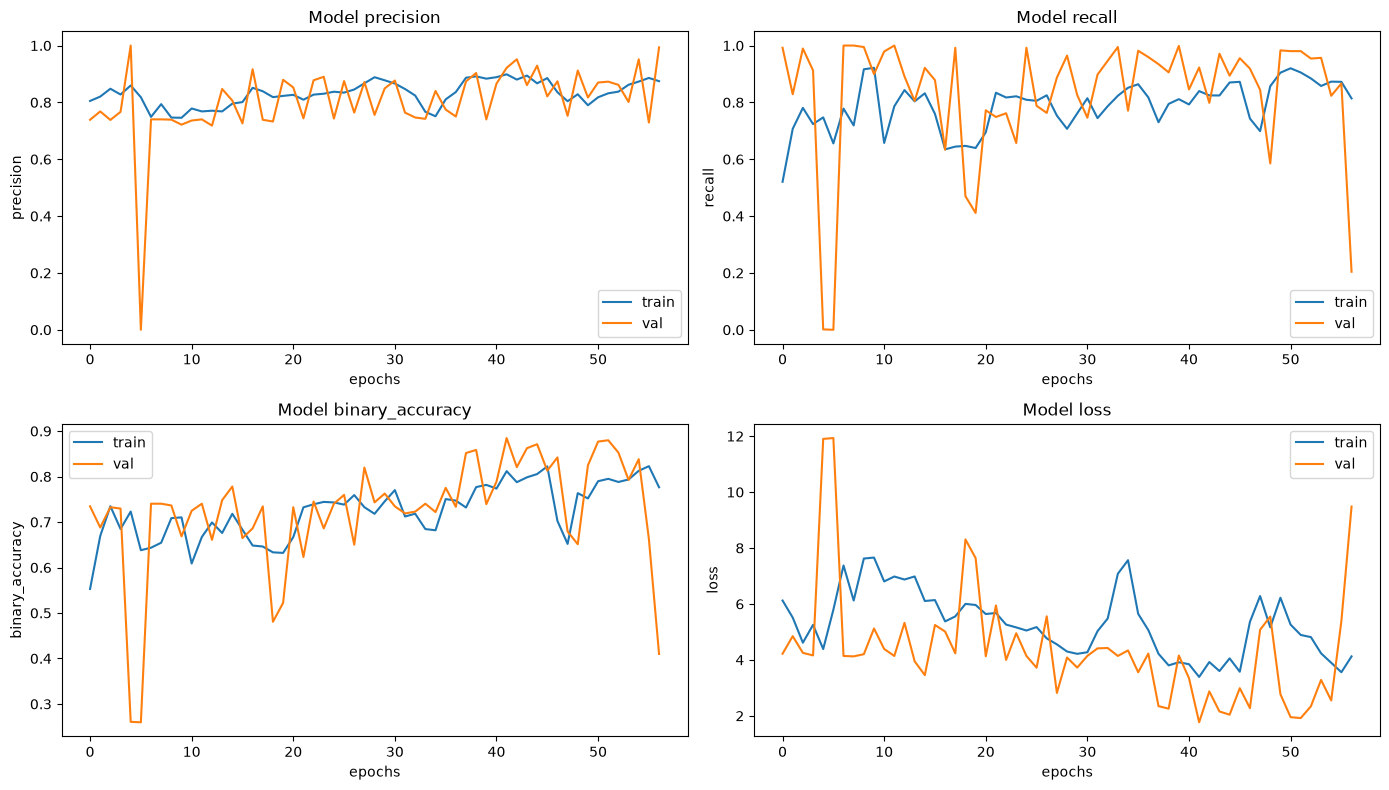

In [49]:
fig2, ax2 = plt.subplots(2, 2, figsize=(14, 8))
ax2 = ax2.ravel()
for i, met in enumerate(["precision", "recall", "binary_accuracy", "loss"]):
    ax2[i].plot(history.history[met])
    ax2[i].plot(history.history["val_" + met])
    ax2[i].set_title(f"Model {met}")
    ax2[i].set_xlabel("epochs")
    ax2[i].set_ylabel(met)
    ax2[i].legend(["train", "val"])
plt.tight_layout()
plt.show()

In [38]:
model.evaluate(test_ds, return_dict=True)

25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - binary_accuracy: 0.7869 - loss: 3.3876 - precision: 0.7824 - recall: 0.9128


{'binary_accuracy': 0.7868589758872986,
 'loss': 3.387622117996216,
 'precision': 0.7824175357818604,
 'recall': 0.9128205180168152}